# A3 (custom CNN) + A4 (ViT-Small) — Colab driver

**Runtime → Change runtime type → T4 GPU**, then run the cells top to bottom.

- Code: read from `MyDrive/csg520_code/src` (upload the `src` folder there once).
- Images: downloaded straight from Kaggle onto Colab's local disk (~2 GB, 1–3 min). Nothing to upload.
- Split: rebuilt with `data.py --build`. It is deterministic (sorted file list + seed 42), so it is the same
  38013 / 8146 / 8146 split A1 used. The notebook checks the counts and stops if they differ, then saves a
  copy to Drive so later runs (and explain.py) reuse that exact file.
- Outputs: `MyDrive/csg520_outputs/` (same folder as A1). A checkpoint is written every epoch.
  **After a disconnect, re-run all cells** and training resumes.

On a T4, A3 takes ~40–60 min and A4 ~1.5–2 h. Run them on two accounts at the same time if you can.

## 1. Paths

In [1]:
from pathlib import Path
CODE_DIR = Path("/content/drive/MyDrive/csg520_code/src")     # where you uploaded src/
OUT_DIR  = Path("/content/drive/MyDrive/csg520_outputs")      # same outputs folder as A1
SPLIT_BACKUP = OUT_DIR / "split"                              # frozen splits.csv + classes.json kept here
LOCAL    = Path("/content/leaf_xai")                          # fast local working copy

In [2]:
from google.colab import drive
drive.mount("/content/drive")
assert (CODE_DIR / "approach3_customcnn.py").exists(), f"upload the src folder to {CODE_DIR}"

Mounted at /content/drive


## 2. Code → local disk, install timm

In [3]:
import shutil
shutil.copytree(CODE_DIR, LOCAL / "src", dirs_exist_ok=True,
                ignore=shutil.ignore_patterns(".git", "__pycache__"))
!pip -q install "timm>=0.9" kagglehub
import torch; print(torch.__version__, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU -- change runtime type!")

2.11.0+cu128 | NVIDIA L4


## 3. PlantVillage from Kaggle → `data/raw`
Public dataset, so normally no login is needed. If the download is refused, add your Kaggle username and API key
as Colab secrets named `KAGGLE_USERNAME` and `KAGGLE_KEY` (key icon in the left sidebar) and re-run.

In [4]:
import os, kagglehub
try:
    from google.colab import userdata
    os.environ.setdefault("KAGGLE_USERNAME", userdata.get("KAGGLE_USERNAME"))
    os.environ.setdefault("KAGGLE_KEY", userdata.get("KAGGLE_KEY"))
except Exception:
    pass   # no secrets set: try anonymous download

ds_path = Path(kagglehub.dataset_download("abdallahalidev/plantvillage-dataset"))
# the colour images (NOT segmented / grayscale): the folder named 'color' holding the 38 class folders
color = next(p for p in sorted(ds_path.rglob("color"))
             if p.is_dir() and sum(1 for c in p.iterdir() if c.is_dir()) == 38)
raw = LOCAL / "data" / "raw"
raw.parent.mkdir(parents=True, exist_ok=True)
if not raw.exists():
    raw.symlink_to(color)
print("using", color, "|", sum(1 for _ in color.rglob("*.*")), "files")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
using /kaggle/input/plantvillage-dataset/plantvillage dataset/color | 54305 files


## 4. Frozen split (rebuilt once, then reused from Drive)

In [5]:
import pandas as pd
data_dir = LOCAL / "data"
if (SPLIT_BACKUP / "splits.csv").exists():
    for f in ("splits.csv", "classes.json"):
        shutil.copy(SPLIT_BACKUP / f, data_dir / f)
    print("reused split from Drive")
else:
    %cd /content/leaf_xai/src
    !python data.py --build

df = pd.read_csv(data_dir / "splits.csv")
counts = df["split"].value_counts().to_dict()
print(counts)
assert counts == {"train": 38013, "val": 8146, "test": 8146}, "NOT the A1 split -- stop and check the dataset folder"
missing = [p for p in df["relpath"] if not (raw / p).exists()]
assert not missing, f"{len(missing)} images missing, e.g. {missing[:3]}"

SPLIT_BACKUP.mkdir(parents=True, exist_ok=True)
for f in ("splits.csv", "classes.json"):
    shutil.copy(data_dir / f, SPLIT_BACKUP / f)
print("split OK and saved to", SPLIT_BACKUP)

reused split from Drive
{'train': 38013, 'test': 8146, 'val': 8146}
split OK and saved to /content/drive/MyDrive/csg520_outputs/split


## 5. Smoke test (~2 min) — tiny subset, throwaway folder

In [6]:
%cd /content/leaf_xai/src
!python approach3_customcnn.py --max-per-class 8 --epochs 1 --output-dir /content/smoke --fresh
!python approach4_vit.py      --max-per-class 8 --warmup-epochs 1 --epochs 1 --output-dir /content/smoke --fresh

/content/leaf_xai/src
[a3_cnn] device=cuda amp=True output=/content/smoke
[a3_cnn] 38 classes | train=304 val=304 test=304
[a3_cnn] CustomCNN parameters: 2,363,654
[a3_cnn] stage 'scratch': epochs 1-1, lr 0.001, wd 0.0001, trainable params 2,363,654
[a3_cnn] epoch 01/1 (scratch) train_loss=3.6407 train_f1=0.0243 | val_loss=3.6296 val_f1=0.0050 (6s)
[a3_cnn]   new best val macro-F1 0.0050 -> a3_cnn.pt

=== A3 / custom CNN / test set ===
  accuracy          : 0.0461
  balanced accuracy : 0.0461
  macro F1          : 0.0173
  weighted F1       : 0.0173
  top-5 accuracy    : 0.1645
  test images       : 304
  macro precision   : 0.0139
  macro recall      : 0.0461
[utils] saved metrics -> /content/smoke/metrics/a3_cnn.json
[utils] saved figure -> /content/smoke/figures/a3_cnn_confusion.png
[utils] saved figure -> /content/smoke/figures/a3_cnn_curves.png
[a3_cnn] saved test probabilities -> /content/smoke/preds/a3_cnn_test_probs.npz
[gradcam] saved figure -> /content/smoke/figures/a3_cnn_gr

## 6. A3 — custom CNN (~40–60 min on T4)
Re-running after a disconnect resumes from the last finished epoch. A copy of the log goes to Drive.

In [ ]:
%cd /content/leaf_xai/src
!python approach3_customcnn.py --epochs 30 --patience 6 --batch-size 64 --lr 1e-3 --workers $(nproc) --output-dir {OUT_DIR} 2>&1 | tee -a {OUT_DIR}/a3_cnn_log.txt

/content/leaf_xai/src
[a3_cnn] device=cuda amp=True output=/content/drive/MyDrive/csg520_outputs
[a3_cnn] 38 classes | train=38013 val=8146 test=8146
[a3_cnn] CustomCNN parameters: 2,363,654
[a3_cnn] resuming after epoch 26/30 (best val macro-F1 so far 0.9931 @ epoch 25)
[a3_cnn] stage 'scratch': epochs 1-30, lr 0.001, wd 0.0001, trainable params 2,363,654
[a3_cnn] epoch 27/30 (scratch) train_loss=0.6563 train_f1=0.9921 | val_loss=0.9862 val_f1=0.9932 (81s)
[a3_cnn]   new best val macro-F1 0.9932 -> a3_cnn.pt
[a3_cnn] epoch 28/30 (scratch) train_loss=0.6564 train_f1=0.9928 | val_loss=0.9836 val_f1=0.9935 (79s)
[a3_cnn]   new best val macro-F1 0.9935 -> a3_cnn.pt
[a3_cnn] epoch 29/30 (scratch) train_loss=0.6545 train_f1=0.9935 | val_loss=0.9847 val_f1=0.9930 (79s)
[a3_cnn] epoch 30/30 (scratch) train_loss=0.6530 train_f1=0.9938 | val_loss=0.9841 val_f1=0.9941 (79s)
[a3_cnn]   new best val macro-F1 0.9941 -> a3_cnn.pt


## 7. A4 — ViT-Small (~1.5–2 h on T4)
Stage 1: 3 epochs, head only, 1e-3. Stage 2: 10 epochs, all layers, 3e-5, cosine, weight decay 0.05.

In [8]:
%cd /content/leaf_xai/src
!python approach4_vit.py --warmup-epochs 3 --epochs 10 --batch-size 64 --lr 3e-5 --workers $(nproc) --output-dir {OUT_DIR} 2>&1 | tee -a {OUT_DIR}/a4_vit_log.txt

/content/leaf_xai/src
[a4_vit] device=cuda amp=True output=/content/drive/MyDrive/csg520_outputs
[a4_vit] vit_small_patch16_224 pretrained=True params=21,680,294 norm mean=(0.5, 0.5, 0.5) std=(0.5, 0.5, 0.5)
[a4_vit] 38 classes | train=38013 val=8146 test=8146
[a4_vit] stage 'warmup': epochs 1-3, lr 0.001, wd 0.05, trainable params 14,630
[a4_vit] epoch 01/13 (warmup) train_loss=1.0100 train_f1=0.8747 | val_loss=1.2248 val_f1=0.9433 (54s)
[a4_vit]   new best val macro-F1 0.9433 -> a4_vit.pt
[a4_vit] epoch 02/13 (warmup) train_loss=0.7960 train_f1=0.9513 | val_loss=1.1794 val_f1=0.9602 (53s)
[a4_vit]   new best val macro-F1 0.9602 -> a4_vit.pt
[a4_vit] epoch 03/13 (warmup) train_loss=0.7700 train_f1=0.9602 | val_loss=1.1759 val_f1=0.9553 (52s)
[a4_vit] stage 'finetune': epochs 4-13, lr 3e-05, wd 0.05, trainable params 21,680,294
[a4_vit] epoch 04/13 (finetune) train_loss=0.7010 train_f1=0.9821 | val_loss=1.0170 val_f1=0.9912 (69s)
[a4_vit]   new best val macro-F1 0.9912 -> a4_vit.pt
[a4

## 8. Results

a3_cnn: acc=0.9961  P=0.9927  R=0.9958  macro-F1=0.9942  best epoch=30
a4_vit: acc=0.9984  P=0.9969  R=0.9980  macro-F1=0.9974  best epoch=12
a3_cnn_curves


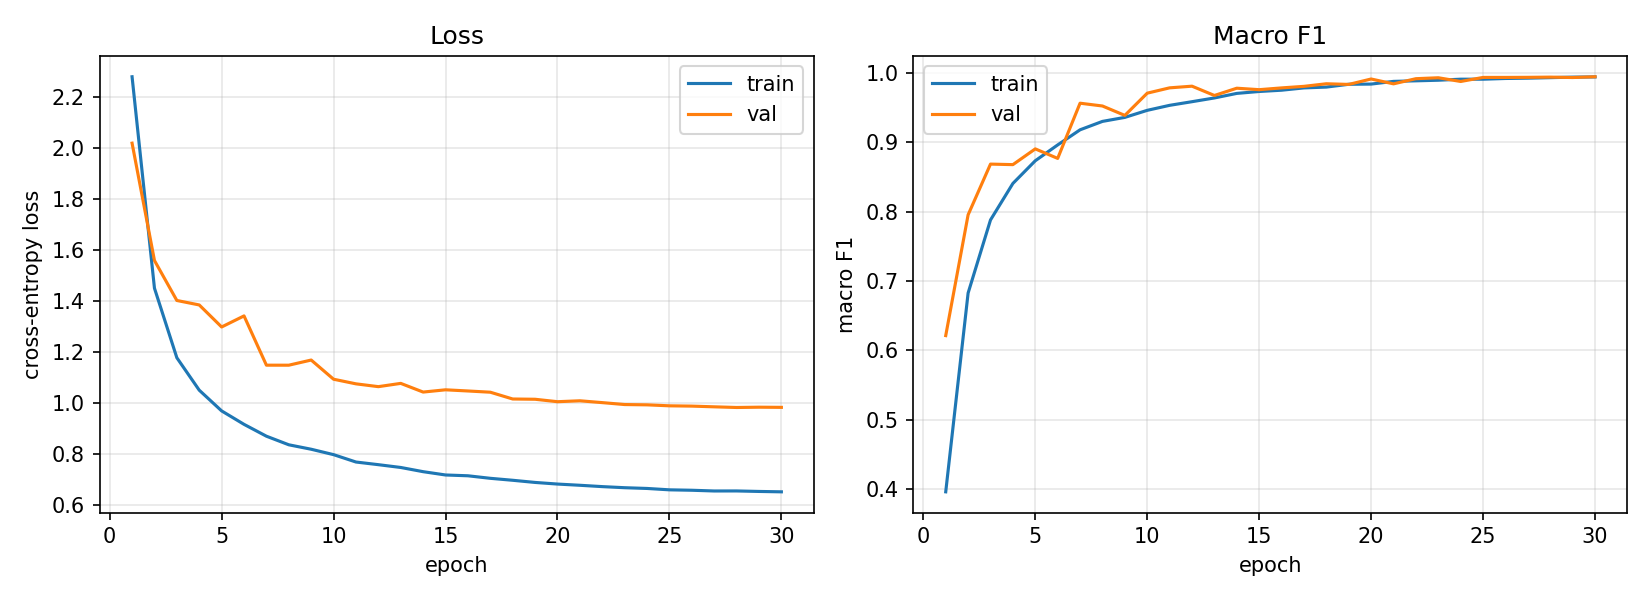

a3_cnn_gradcam


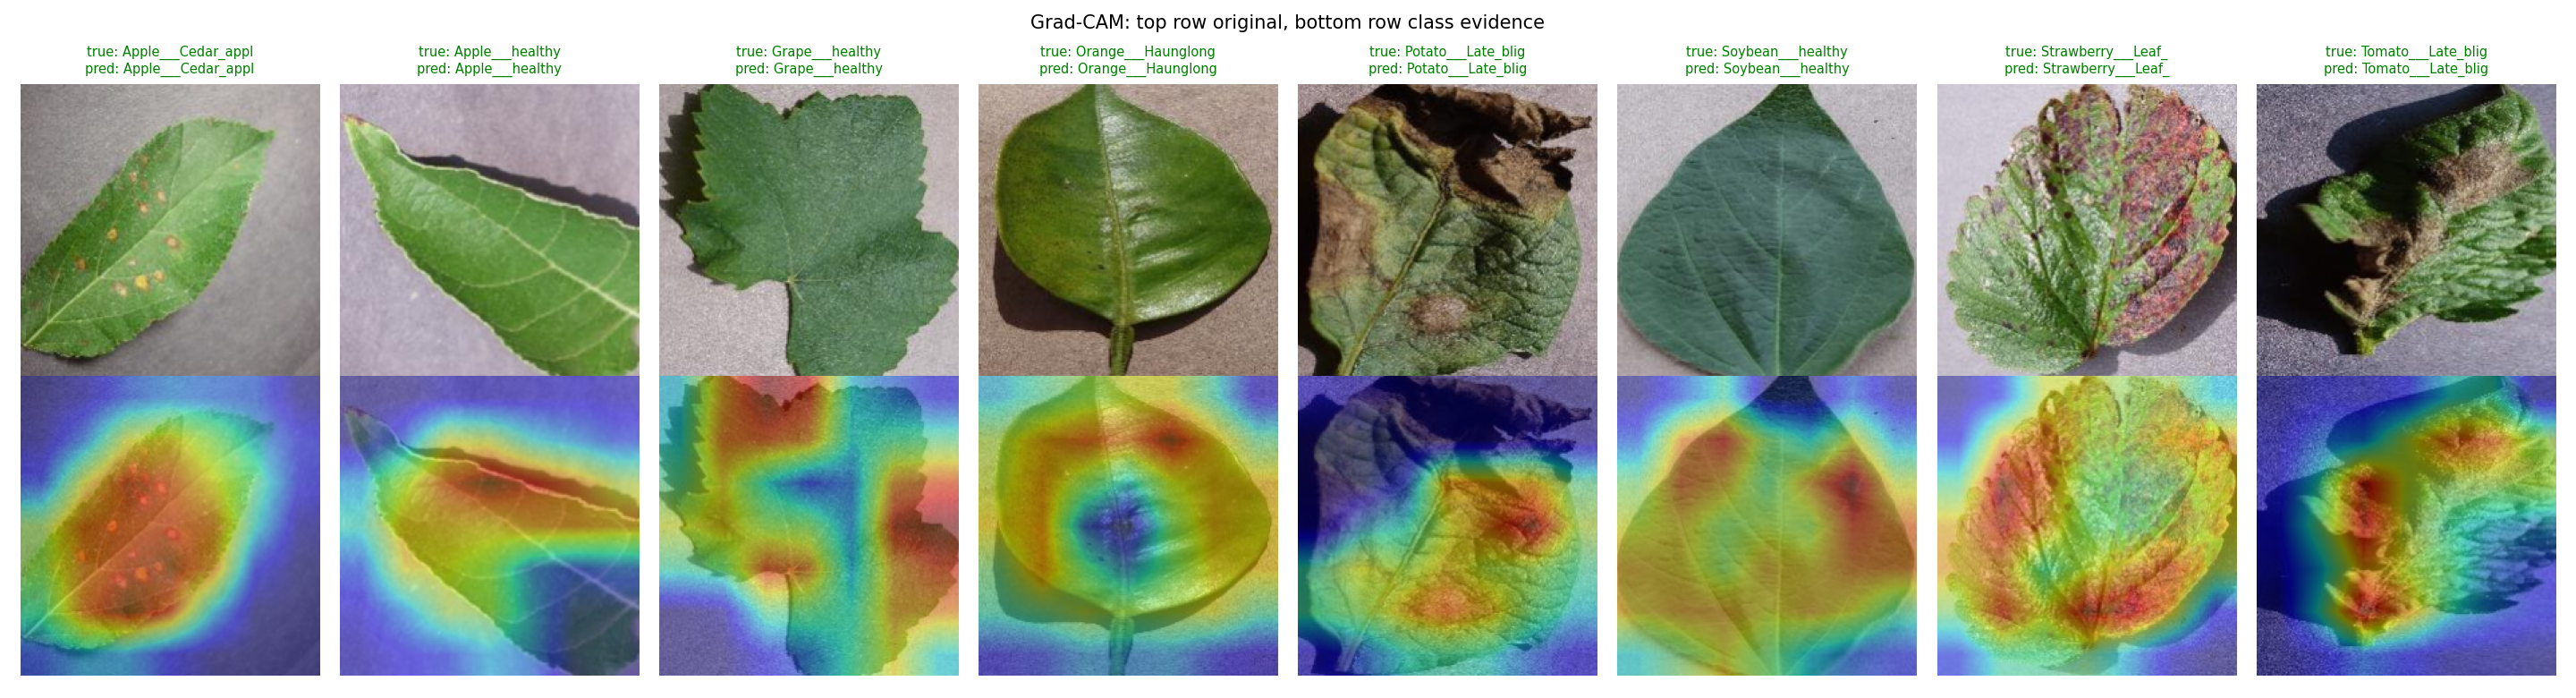

a4_vit_curves


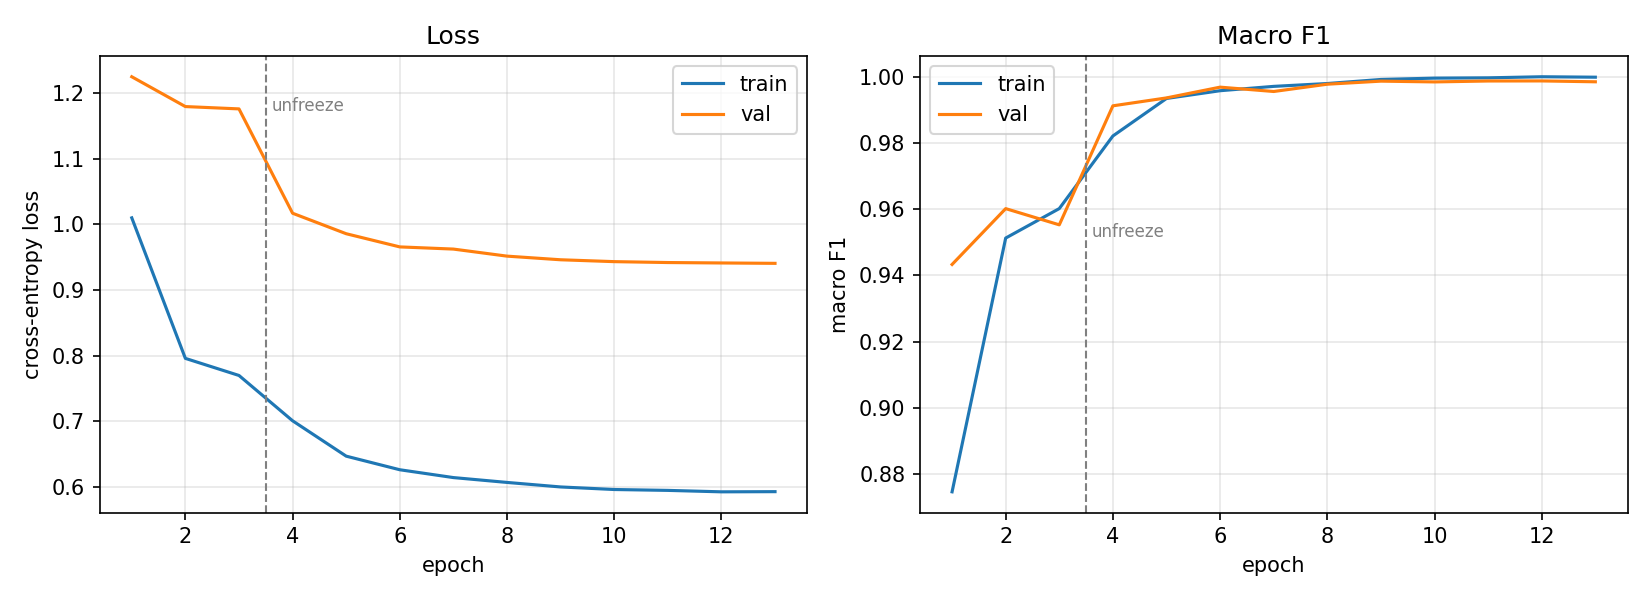

a4_vit_attention


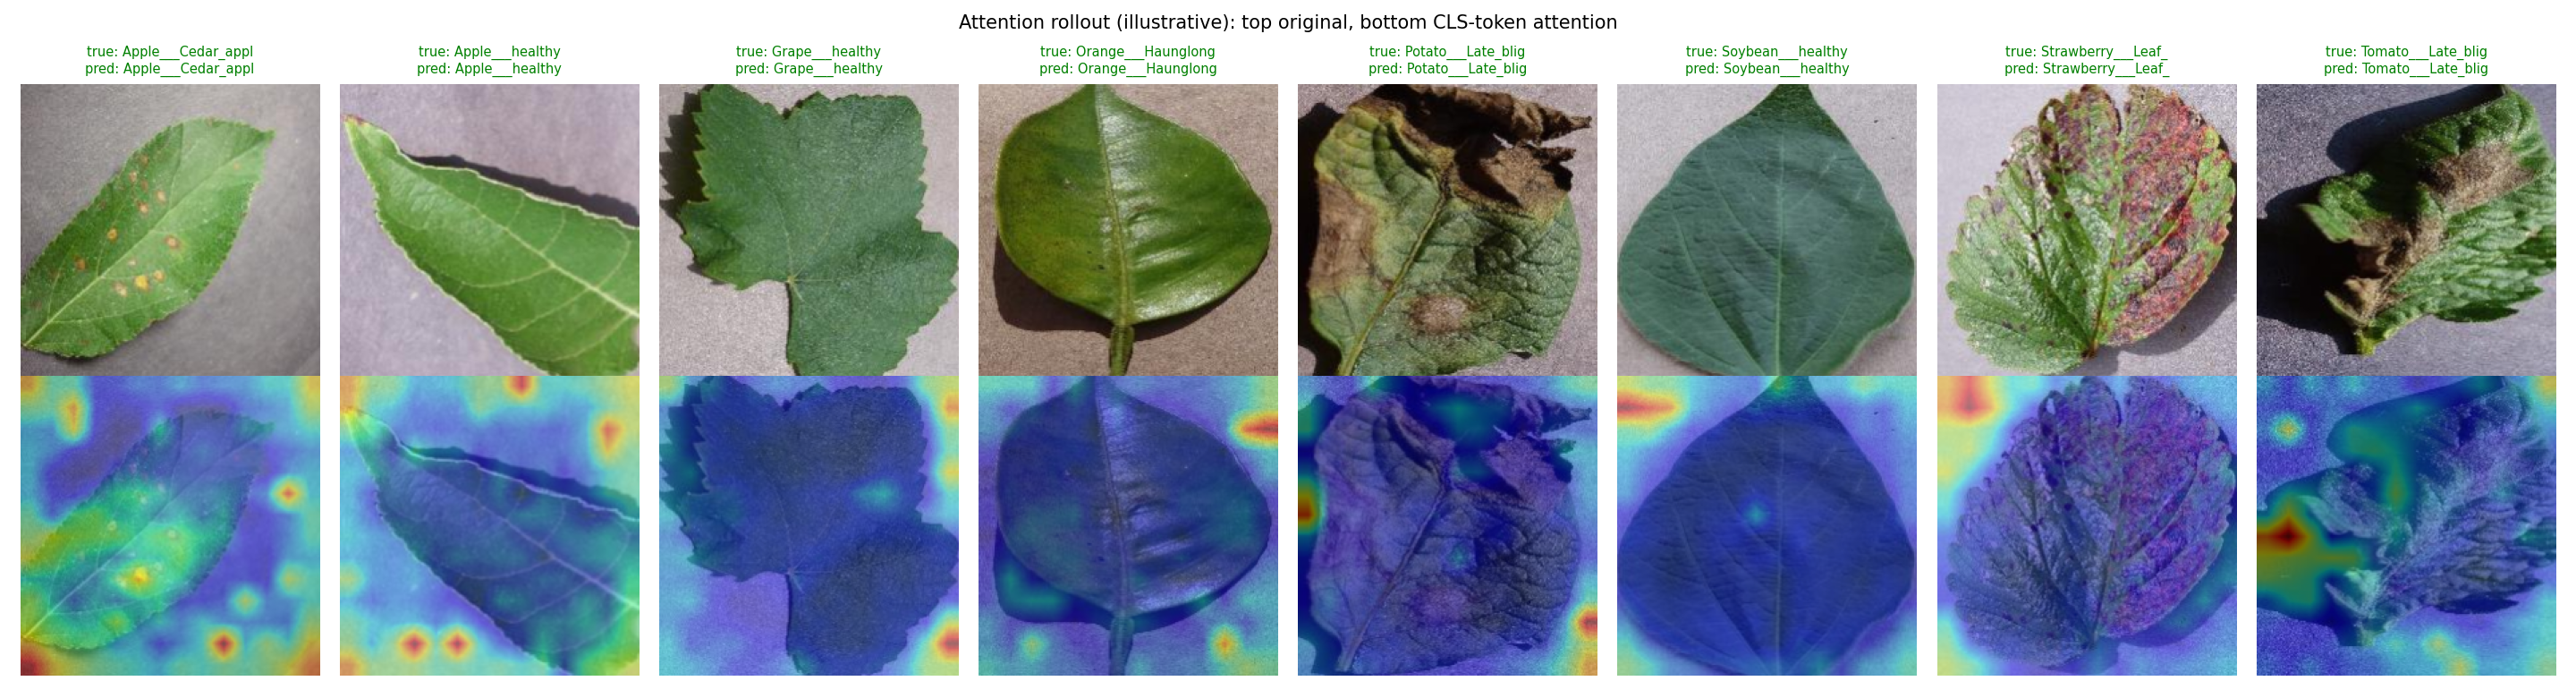

In [9]:
import json
for tag in ("a3_cnn", "a4_vit"):
    f = OUT_DIR / "metrics" / f"{tag}.json"
    if f.exists():
        m = json.loads(f.read_text())
        print(f"{tag}: acc={m['accuracy']:.4f}  P={m['macro_precision']:.4f}  R={m['macro_recall']:.4f}  "
              f"macro-F1={m['macro_f1']:.4f}  best epoch={m.get('history', {}).get('best_epoch')}")
from IPython.display import Image, display
for name in ("a3_cnn_curves", "a3_cnn_gradcam", "a4_vit_curves", "a4_vit_attention"):
    p = OUT_DIR / "figures" / f"{name}.png"
    if p.exists():
        print(name); display(Image(str(p)))